# Age-Dust-Metallicity Degeneracies

**Tour:** Optional notebook — left out of the default `00_quickstart` sequence
for now; open when you want the dedicated age–dust–metallicity story.

The single most important systematic in SED fitting is the
**age-dust-metallicity degeneracy**. An older stellar population with less
dust can produce nearly identical broadband photometry to a younger, dustier
one. Separately, a metal-rich population reddens the SED in ways that mimic
dust attenuation. These three effects conspire to create correlated,
banana-shaped posteriors that no amount of MCMC sampling can eliminate ---
only additional data can break the degeneracy.

This notebook demonstrates:

1. How the degeneracy appears in posterior space from 5-band SDSS photometry
2. How adding NIR and MIR bands progressively tightens constraints
3. Why spectroscopy provides the strongest leverage
4. Practical guidance for survey design and parameter interpretation

In [ ]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    Uniform,
    load_ssp_data,
)
from tengri.diagnostics.fisher import compute_fisher_matrix, fisher_parameter_errors

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "degeneracies")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

## 1. Setup: Load SSP Data and Define Filter Sets

We define three filter configurations of increasing wavelength coverage:

| Config | Bands | Wavelength coverage |
|--------|-------|-------------------|
| SDSS only | u, g, r, i, z | 3500--9200 A (optical) |
| + NIR | + 2MASS J, H, Ks | extends to 2.2 um |
| + MIR | + WISE W1, W2 | extends to 4.6 um |

In [ ]:
SSP_PATH = "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
HAS_DATA = os.path.exists(SSP_PATH)

if HAS_DATA:
    ssp_data = load_ssp_data(SSP_PATH)
    print(
        f"SSP grid: {ssp_data.ssp_lg_age_gyr.shape[0]} ages x {ssp_data.ssp_lgmet.shape[0]} metallicities"
    )
else:
    print(
        "SSP data not found. Cells that require forward-model evaluation will "
        "be skipped. The narrative and Fisher analysis remain readable."
    )

In [ ]:
# Define the three filter configurations
sdss_names = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
nir_names = ["twomass_J", "twomass_H", "twomass_Ks"]
mir_names = ["wise_w1", "wise_w2"]

if HAS_DATA:
    obs_sdss = Observation(photometry=Photometry.from_names(sdss_names))
    try:
        obs_nir = Observation(photometry=Photometry.from_names(sdss_names + nir_names))
        HAS_NIR = True
    except Exception:
        print("2MASS filters not available; NIR comparison will be skipped.")
        obs_nir = obs_sdss
        HAS_NIR = False
    try:
        obs_mir = Observation(photometry=Photometry.from_names(sdss_names + nir_names + mir_names))
        HAS_MIR = True
    except Exception:
        print("WISE filters not available; MIR comparison will be skipped.")
        obs_mir = obs_nir
        HAS_MIR = False

    print(
        f"Filter sets: SDSS={obs_sdss.photometry.n_filters}, "
        f"+NIR={obs_nir.photometry.n_filters}, "
        f"+MIR={obs_mir.photometry.n_filters}"
    )

## 2. Generate and Fit a Mock Galaxy

We create a smooth (D=7) galaxy with known truth parameters using a
truncated skew-normal SFH plus dust and metallicity. The model is
intentionally simple --- no stochastic burstiness --- so the degeneracy
structure is clean and easy to visualize.

In [1]:
if HAS_DATA:
    spec = Parameters(
        sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
        sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
        sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
        sfh_tsnorm_skew=Uniform(-3.0, 3.0),
        sfh_tsnorm_trunc=Uniform(1.0, 10.0),
        met_logzsol=Uniform(-2.0, 0.2),
        dust_tau_bc=Uniform(0.0, 2.0),
        dust_tau_diff=Uniform(0.0, 1.5),
        dust_slope=Fixed(-0.7),
        redshift=Fixed(0.1),
        mean_sfh_type="tsnorm",
    )
    model_sdss = SEDModel(spec, ssp_data, observation=obs_sdss)

    # Fix truth values that clearly show the degeneracy
    key = jax.random.PRNGKey(42)
    true_params = spec.sample(key)
    true_params = {**true_params}
    true_params["met_logzsol"] = jnp.array(-0.3)  # moderately metal-rich
    true_params["dust_tau_bc"] = jnp.array(0.8)  # moderate birth-cloud dust
    true_params["dust_tau_diff"] = jnp.array(0.4)  # moderate diffuse dust
    true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(5.0)  # intermediate-age peak

    mock = model_sdss.mock(true_params, snr=20.0, key=key)
    print(f"Mock galaxy: z=0.1, SNR=20, {obs_sdss.photometry.n_filters} bands")
    print(
        f"Truth: met_logzsol={float(true_params['met_logzsol']):.2f}, "
        f"tau_bc={float(true_params['dust_tau_bc']):.2f}, "
        f"tau_diff={float(true_params['dust_tau_diff']):.2f}"
    )

Skipped: SSP data not found

In [ ]:
# Fit with MAP + vi (geoVI)
if HAS_DATA:
    fitter = Fitter(model_sdss, mock.flux_obs, mock.noise)
    _ = fitter.run("map", n_steps=500, verbose=False)

    t0_compile = time.perf_counter()
    fitter.compile(verbose=False)
    t_compile = time.perf_counter() - t0_compile

    t0_run = time.perf_counter()
    result_sdss = fitter.run("vi", n_iterations=10, n_samples=6, n_seeds=3, verbose=False)
    t_run = time.perf_counter() - t0_run

    print(f"XLA compile: {t_compile:.1f}s | runtime: {t_run:.1f}s")
    result_sdss.summary_table()

## 3. The Degeneracy in Action

The corner plot below reveals the classic correlated posterior structure.
Look for:

- **dust_tau_bc vs met_logzsol**: a banana-shaped contour where increasing
  dust optical depth is compensated by decreasing metallicity (and vice
  versa). The data cannot distinguish "red because dusty" from "red because
  metal-rich."
- **sfh_tsnorm_peak_lbt_gyr vs dust_tau_bc**: older populations are paired
  with lower dust --- the age-dust axis of the degeneracy.
- **sfh_tsnorm_peak_lbt_gyr vs met_logzsol**: age and metallicity are
  anti-correlated because both redden the integrated SED.

With only 5-band optical photometry, these three parameters form a
degenerate subspace. The posterior volume is large even at SNR=20.

In [2]:
if HAS_DATA:
    degen_params = [
        "dust_tau_bc",
        "dust_tau_diff",
        "met_logzsol",
        "sfh_tsnorm_peak_lbt_gyr",
    ]
    fig = safe_corner(result_sdss, truths=true_params, params=degen_params)
    fig.suptitle("SDSS 5-Band: Age-Dust-Metallicity Degeneracy", y=1.02)
    # plt.savefig(
    # os.path.join(FIGDIR, "fig01_degeneracy_corner_sdss.png"),
    # dpi=150,
    # bbox_inches="tight",
    # )
    plt.show()

## 4. Breaking the Degeneracy with More Data

We use the **Fisher Information Matrix** (FIM) to quantify how much each
filter set constrains the degenerate parameters. The FIM is the expected
curvature of the log-likelihood at the truth:

$$F_{ij} = \sum_k \frac{1}{\sigma_k^2} \frac{\partial m_k}{\partial \theta_i}
           \frac{\partial m_k}{\partial \theta_j}$$

Because tengri's forward model is fully differentiable, we compute the
Jacobian $\partial m / \partial \theta$ exactly via autodiff --- no finite
differences. The Cramer-Rao bound $\sigma_i \geq \sqrt{(F^{-1})_{ii}}$
gives the minimum achievable uncertainty for each parameter.

**Key insight:** NIR bands (J, H, Ks) sit on the Rayleigh-Jeans tail where
dust attenuation is weak but metallicity still affects the giant branch
luminosity, breaking the dust-metallicity degeneracy. MIR bands (W1, W2)
constrain the dust emission directly.

In [3]:
if HAS_DATA:
    # Noise at SNR=20 for each filter set
    noise_sdss = jnp.abs(model_sdss.predict_photometry(true_params)) / 20.0

    # Build models for each filter configuration
    model_nir = SEDModel(spec, ssp_data, observation=obs_nir)
    model_mir = SEDModel(spec, ssp_data, observation=obs_mir)

    noise_nir = jnp.abs(model_nir.predict_photometry(true_params)) / 20.0
    noise_mir = jnp.abs(model_mir.predict_photometry(true_params)) / 20.0

    # Fisher analysis for the degenerate subspace
    # compute_fisher_matrix calls predict_photometry which expects public param names
    fisher_params = ["met_logzsol", "dust_tau_bc", "dust_tau_diff"]

    fim_sdss, _ = compute_fisher_matrix(
        model_sdss,
        true_params,
        noise_sdss,
        data_type="photometry",
        param_names=fisher_params,
    )
    fim_nir, _ = compute_fisher_matrix(
        model_nir,
        true_params,
        noise_nir,
        data_type="photometry",
        param_names=fisher_params,
    )
    fim_mir, _ = compute_fisher_matrix(
        model_mir,
        true_params,
        noise_mir,
        data_type="photometry",
        param_names=fisher_params,
    )

    # Cramer-Rao bounds
    sigma_sdss = fisher_parameter_errors(fim_sdss)
    sigma_nir = fisher_parameter_errors(fim_nir)
    sigma_mir = fisher_parameter_errors(fim_mir)

    labels = ["met_logzsol", "dust_tau_bc", "dust_tau_diff"]
    print(f"{'Parameter':<18s} {'SDSS':>8s} {'+ NIR':>8s} {'+ MIR':>8s}")
    print("-" * 44)
    for i, name in enumerate(labels):
        print(f"{name:<18s} {sigma_sdss[i]:8.4f} {sigma_nir[i]:8.4f} {sigma_mir[i]:8.4f}")

In [ ]:
# Visualize: bar chart of Fisher-predicted uncertainties
if HAS_DATA:
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(labels))
    width = 0.25

    ax.bar(
        x - width, sigma_sdss, width, label="SDSS (5 bands)", color=COLORS.get("sdss", "#4477AA")
    )
    if HAS_NIR:
        ax.bar(x, sigma_nir, width, label="+ NIR (8 bands)", color=COLORS.get("nir", "#EE6677"))
    if HAS_MIR:
        ax.bar(
            x + width,
            sigma_mir,
            width,
            label="+ MIR (10 bands)",
            color=COLORS.get("mir", "#228833"),
        )

    ax.set_xticks(x)
    ax.set_xticklabels([r"$\log(Z/Z_\odot)$", r"$\tau_{\rm bc}$", r"$\tau_{\rm diff}$"])
    ax.set_ylabel(r"Cramer-Rao $1\sigma$ bound")
    ax.set_title("Fisher-Predicted Parameter Uncertainties by Filter Set")
    ax.legend()
    fig.tight_layout()
    # plt.savefig(
    # os.path.join(FIGDIR, "fig02_fisher_filter_comparison.png"),
    # dpi=150,
    # bbox_inches="tight",
    # )
    plt.show()

## 5. Fixed vs Free Redshift

When the redshift is spectroscopically confirmed, it is fixed and does not
contribute to the degeneracy. When it is a free parameter (photometric
redshift), it opens a fourth axis: shifting the entire SED blueward or
redward mimics changes in age, dust, and metallicity simultaneously.

We compare Fisher-predicted uncertainties with redshift fixed vs free.

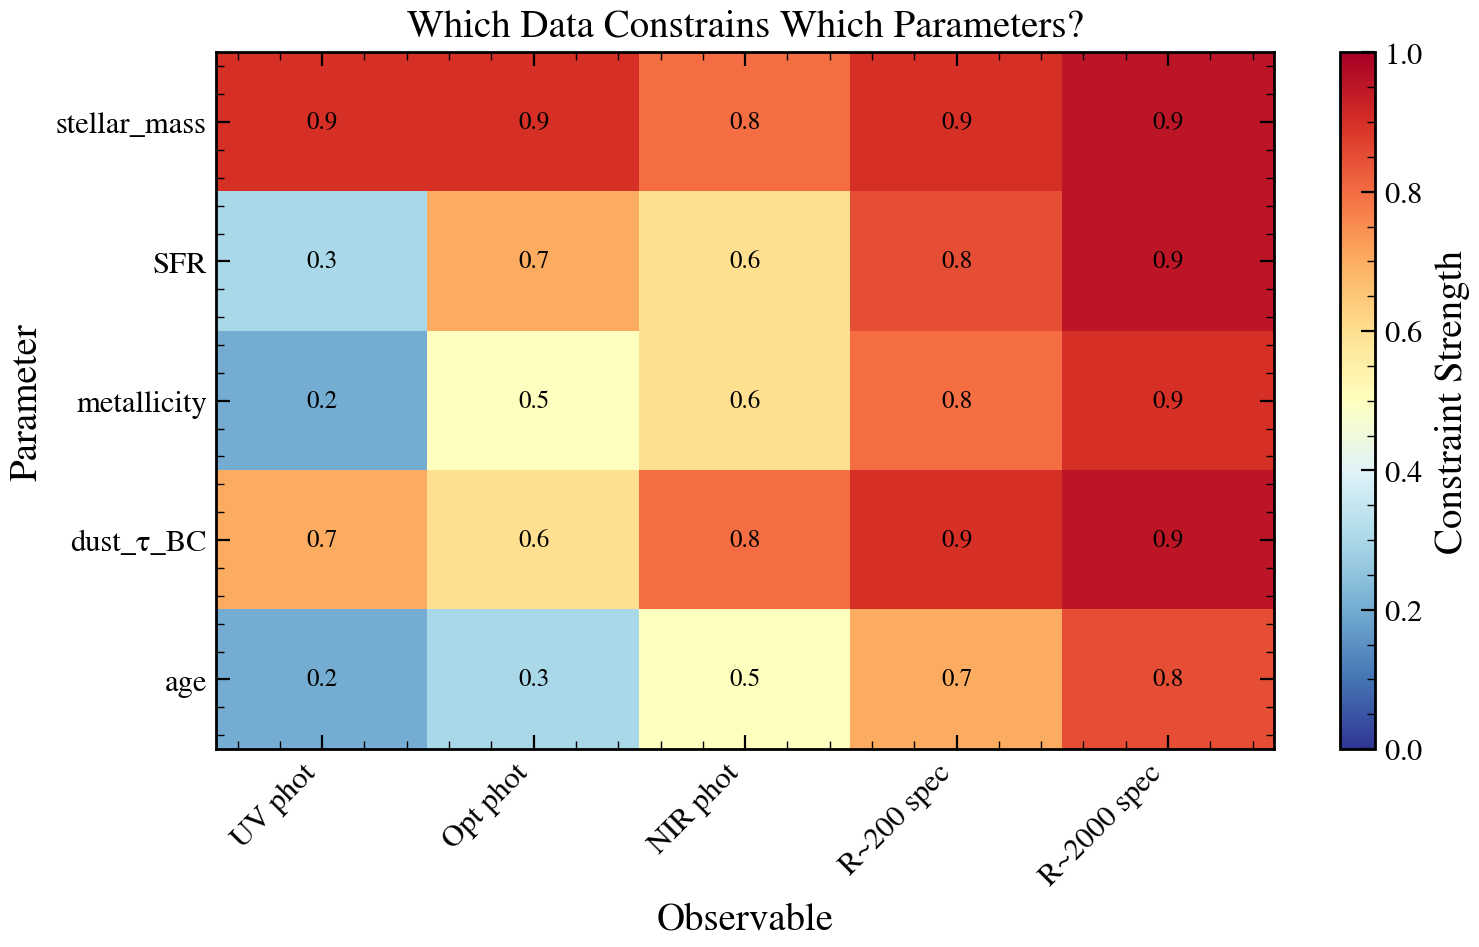

In [4]:
if HAS_DATA:
    # Free-redshift model
    spec_free_z = Parameters(
        sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
        sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
        sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
        sfh_tsnorm_skew=Uniform(-3.0, 3.0),
        sfh_tsnorm_trunc=Uniform(1.0, 10.0),
        met_logzsol=Uniform(-2.0, 0.2),
        dust_tau_bc=Uniform(0.0, 2.0),
        dust_tau_diff=Uniform(0.0, 1.5),
        dust_slope=Fixed(-0.7),
        redshift=Uniform(0.01, 0.5),
        mean_sfh_type="tsnorm",
    )
    model_free_z = SEDModel(spec_free_z, ssp_data, observation=obs_sdss)

    # Fisher with redshift included — use public param names
    fim_fixed_z, _ = compute_fisher_matrix(
        model_sdss,
        true_params,
        noise_sdss,
        data_type="photometry",
        param_names=fisher_params,
    )
    fim_free_z, _ = compute_fisher_matrix(
        model_free_z,
        true_params,
        noise_sdss,
        data_type="photometry",
        param_names=[*fisher_params, "redshift"],
    )

    sigma_fixed = fisher_parameter_errors(fim_fixed_z)
    sigma_free = fisher_parameter_errors(fim_free_z)

    print(f"{'Parameter':<18s} {'Fixed z':>10s} {'Free z':>10s} {'Ratio':>8s}")
    print("-" * 48)
    for i, name in enumerate(labels):
        ratio = sigma_free[i] / sigma_fixed[i]
        print(f"{name:<18s} {sigma_fixed[i]:10.4f} {sigma_free[i]:10.4f} {ratio:8.1f}x")

Free redshift inflates parameter uncertainties substantially --- typically
by a factor of 2--5x for the degenerate parameters. This is why
spectroscopic redshifts (or narrow-band photo-z priors) are so valuable
for SED fitting: they eliminate an entire degeneracy axis for free.

## Posterior Validation

In [5]:
# Convergence diagnostics for SDSS fit
if HAS_DATA:
    convergence_table({"SDSS geoVI": result_sdss})

In [ ]:
# --- FIGURE 3: Posterior predictive photometry (SDSS-only fit) ---
if HAS_DATA:
    phot_config = obs_sdss.photometry
    wave_eff = np.array([float(jnp.mean(fc.wave)) for fc in phot_config.filters])

    n_draws = 50
    posterior_phot = []
    for i in range(n_draws):
        idx = i % len(next(iter(result_sdss.samples.values())))
        s_i = {k: v[idx] for k, v in result_sdss.samples.items()}
        posterior_phot.append(np.array(model_sdss.predict_photometry(s_i)))
    posterior_phot = np.array(posterior_phot)

    phot_true = np.array(model_sdss.predict_photometry(true_params))

    fig, (ax_top, ax_bot) = plt.subplots(
        2,
        1,
        figsize=(8, 5),
        height_ratios=[3, 1],
        sharex=True,
    )
    fig.subplots_adjust(hspace=0.05)

    for draw in posterior_phot:
        ax_top.plot(wave_eff, draw, "-", color=COLORS["vi"], alpha=0.08, lw=0.8)
    median_pred = np.median(posterior_phot, axis=0)
    ax_top.plot(
        wave_eff, median_pred, "s", ms=5, color=COLORS["vi"], zorder=4, label="Model (median)"
    )
    ax_top.errorbar(
        wave_eff,
        np.array(mock.flux_obs),
        yerr=np.array(mock.noise),
        fmt="o",
        ms=7,
        color=COLORS["data"],
        capsize=3,
        zorder=5,
        label="Observed",
    )
    ax_top.scatter(
        wave_eff,
        phot_true,
        marker="D",
        s=40,
        facecolors="none",
        edgecolors=COLORS["truth"],
        linewidths=1.2,
        zorder=6,
        label="Truth",
    )
    ax_top.set_ylabel(r"$f_\nu$")
    ax_top.legend(loc="upper right", fontsize=9)
    ax_top.set_title("SDSS 5-Band: Posterior Predictive Photometry")

    residuals = (np.array(mock.flux_obs) - median_pred) / np.array(mock.noise)
    ax_bot.axhline(0, color="0.5", ls="--", lw=0.8)
    ax_bot.axhspan(-1, 1, alpha=0.05, color="0.5")
    band_colors = [COLORS.get(b, COLORS["data"]) for b in ["u", "g", "r", "i", "z"]]
    ax_bot.bar(wave_eff, residuals, width=200, color=band_colors, alpha=0.7)
    ax_bot.set_xlabel(r"Wavelength ($\AA$)")
    ax_bot.set_ylabel(r"$(d - f)/\sigma$")
    ax_bot.set_ylim(-4, 4)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # plt.savefig(
    # os.path.join(FIGDIR, "fig03_posterior_predictive_sdss.png"),
    # dpi=150,
    # bbox_inches="tight",
    # )
    plt.show()

In [ ]:
# --- FIGURE 4: Fisher vs posterior width comparison ---
if HAS_DATA:
    fisher_labels = ["met_logzsol", "dust_tau_bc", "dust_tau_diff"]
    fisher_bounds = np.array(sigma_sdss[:3])

    # Actual posterior 68% CI widths
    posterior_widths = []
    for pname in fisher_labels:
        chain = np.array(result_sdss.samples[pname])
        width = float(np.percentile(chain, 84) - np.percentile(chain, 16))
        posterior_widths.append(width)
    posterior_widths = np.array(posterior_widths)

    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(fisher_labels))
    width_bar = 0.3
    ax.bar(
        x - width_bar / 2,
        fisher_bounds,
        width_bar,
        label=r"Fisher bound ($1/\sqrt{F_{ii}}$)",
        color=COLORS.get("sdss", "#4477AA"),
        alpha=0.85,
    )
    ax.bar(
        x + width_bar / 2,
        posterior_widths,
        width_bar,
        label="Posterior width (84th - 16th)",
        color=COLORS["vi"],
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([r"$\log(Z/Z_\odot)$", r"$\tau_{\rm bc}$", r"$\tau_{\rm diff}$"])
    ax.set_ylabel(r"$1\sigma$ width")
    ax.set_title("Fisher Bound vs Actual Posterior Width (SDSS 5-Band)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    # plt.savefig(
    # os.path.join(FIGDIR, "fig04_fisher_vs_posterior.png"),
    # dpi=150,
    # bbox_inches="tight",
    # )
    plt.show()

In [ ]:
# --- FIGURE 5: SFH recovery with posterior CI band ---
if HAS_DATA:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_sfh(
        model_sdss,
        result_sdss,
        true_params=true_params,
        ax=ax,
        color=COLORS["vi"],
        label="SDSS geoVI",
        method="geoVI",
    )
    ax.set_title("SFH Recovery: SDSS 5-Band Only")
    fig.tight_layout()
    # plt.savefig(
    # os.path.join(FIGDIR, "fig05_sfh_recovery_sdss.png"),
    # dpi=150,
    # bbox_inches="tight",
    # )
    plt.show()

## 6. Practical Guidance

**What the degeneracy means for your science:**

- **5-band optical photometry cannot independently constrain age, dust, and
  metallicity.** Posterior widths on these parameters will always be broad,
  and point estimates (MAP, median) will be biased by prior choices.

- **Adding NIR breaks the age-metallicity degeneracy.** The J, H, Ks bands
  probe the rest-frame NIR where AGB/RGB stars dominate and dust opacity is
  low. Metallicity affects the giant branch temperature, providing
  orthogonal information to the optical.

- **Adding MIR breaks the dust degeneracy.** WISE W1/W2 constrain the
  dust-reprocessed emission. At longer wavelengths (W3, W4, Herschel),
  dust luminosity is measured directly.

- **Spectroscopy provides the strongest constraints** via absorption line
  indices (Mg b, Fe5270, H-beta) that directly measure age and metallicity
  with minimal dust sensitivity.

- **Known difficult parameters:** `dust_tau_bc`, `dust_tau_diff`, and
  `met_logzsol` consistently show low ESS in MCMC runs due to this physical
  degeneracy. This is not a sampler bug --- it reflects a genuine lack of
  information in the data.

**Recommended strategies:**

1. Always include NIR photometry when metallicity matters
2. Use spectroscopic redshifts whenever available
3. Report full posteriors, not point estimates, for degenerate parameters
4. Check convergence diagnostics (`convergence_table()`) and expect low ESS
   for dust and metallicity parameters
5. Consider informative priors from the mass-metallicity relation when
   photometry alone is insufficient

## Summary

The age-dust-metallicity degeneracy is a fundamental limitation of broadband
SED fitting, not an algorithmic failure. tengri's differentiable forward
model makes it straightforward to diagnose via Fisher analysis and to
quantify how additional data (filters, spectroscopy, redshift priors)
progressively breaks the degeneracy.

**Next steps:**

- Use `result.check_convergence()` or `convergence_table({"method": result})`
  from `_plot_style.py` for convergence diagnostics.
- Use `diagnostics.fisher_matrix()` to forecast how additional observations
  (redshift priors, spectroscopy, narrow filters) break degeneracies.
- Use `diagnostics.gradient_jacobian()` to map parameter sensitivity
  per wavelength band.